# MagicFace Reproduction

**Paper**

MagicFace: High-Fidelity Facial Expression Editing with Action-Unit Control

**Goal**

Reproduce the official MagicFace inference pipeline, generate AU-controlled facial expression edits, and prepare the project for quantitative evaluation and video experiments.

## MagicFace: AU-Controlled Facial Expression Editing
Research Reproduction and Video Extension

In [1]:
# Cell 1: Mount Google Drive and define persistent project paths

from pathlib import Path
import os, json, sys, subprocess, time, shutil

IN_COLAB = False

try:
    from google.colab import drive

    # Mount only if not already mounted
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

    IN_COLAB = True

except Exception as e:
    print(e)

PROJECT_ROOT = Path('/content/drive/MyDrive/magicface_reproduction') if IN_COLAB else Path.cwd() / 'magicface_reproduction'

REPO_DIR     = PROJECT_ROOT / 'official_MagicFace'
WORK_DIR     = PROJECT_ROOT / 'my_work'
MODEL_DIR    = PROJECT_ROOT / 'models'
HF_HOME      = PROJECT_ROOT / 'hf_cache'
PIP_CACHE    = PROJECT_ROOT / 'pip_cache'
RESULTS_DIR  = PROJECT_ROOT / 'results'
LOG_DIR      = PROJECT_ROOT / 'logs'
STATE_DIR    = PROJECT_ROOT / 'state'
SCRIPTS_DIR  = WORK_DIR / 'scripts'

for p in [
    PROJECT_ROOT, REPO_DIR, WORK_DIR, MODEL_DIR, HF_HOME,
    PIP_CACHE, RESULTS_DIR, LOG_DIR, STATE_DIR, SCRIPTS_DIR
]:
    p.mkdir(parents=True, exist_ok=True)

# These environment variables make Hugging Face and pip reuse Drive caches.
os.environ['HF_HOME'] = str(HF_HOME)
os.environ['TRANSFORMERS_CACHE'] = str(HF_HOME / 'transformers')
os.environ['DIFFUSERS_CACHE'] = str(HF_HOME / 'diffusers')
os.environ['PIP_CACHE_DIR'] = str(PIP_CACHE)

STATE = {
    "PROJECT_ROOT": str(PROJECT_ROOT),
    "REPO_DIR": str(REPO_DIR),
    "WORK_DIR": str(WORK_DIR),
    "MODEL_DIR": str(MODEL_DIR),
    "RESULTS_DIR": str(RESULTS_DIR),
    "HF_HOME": str(HF_HOME),
}

(STATE_DIR / "paths.json").write_text(json.dumps(STATE, indent=2))

print("Project paths created:")
print(json.dumps(STATE, indent=2))

Project paths created:
{
  "PROJECT_ROOT": "/content/drive/MyDrive/magicface_reproduction",
  "REPO_DIR": "/content/drive/MyDrive/magicface_reproduction/official_MagicFace",
  "WORK_DIR": "/content/drive/MyDrive/magicface_reproduction/my_work",
  "MODEL_DIR": "/content/drive/MyDrive/magicface_reproduction/models",
  "RESULTS_DIR": "/content/drive/MyDrive/magicface_reproduction/results",
  "HF_HOME": "/content/drive/MyDrive/magicface_reproduction/hf_cache"
}


## Part 2 — Initial Setup

This section:

- checks GPU
- clones the official MagicFace repository
- downloads required models
- prepares the working directory

These cells only need to be run once unless starting from scratch.

In [2]:
# Cell 2: Check GPU, Python, Torch, and CUDA

import torch, subprocess, sys, os

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

# nvidia-smi gives detailed GPU memory information.
subprocess.run(["nvidia-smi"], check=False)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA: 12.8


CompletedProcess(args=['nvidia-smi'], returncode=0)

In [ ]:
# Cell 3: Clone or update the official MagicFace repo in Drive

import subprocess
from pathlib import Path

repo_url = "https://github.com/weimengting/MagicFace.git"

if not (REPO_DIR / ".git").exists():
    print("Cloning official MagicFace repo...")
    subprocess.check_call(["git", "clone", repo_url, str(REPO_DIR)])
else:
    print("Repo already exists. Pulling latest changes if possible...")
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=False)

print("Repo path:", REPO_DIR)
print("First files/folders in repo:")
print(sorted([p.name for p in REPO_DIR.iterdir()])[:30])

Repo already exists. Pulling latest changes if possible...
Repo path: /content/drive/MyDrive/magicface_reproduction/official_MagicFace
First files/folders in repo:
['.cache', '.git', '.gitattributes', '.idea', '79999_iter.pth', 'ID_enc', 'LICENSE', 'README.md', 'assets', 'checkpoints', 'denoising_unet', 'inference.py', 'mgface', 'requirements.txt', 'test_images', 'third_party', 'third_party_files', 'utils']


In [4]:
# ============================================================
# Cell 4
# Runtime Environment Setup (Version-aware)
# ============================================================

import subprocess
import sys
import importlib
from pathlib import Path

print("=" * 60)
print("Checking Runtime Environment")
print("=" * 60)

required_versions = {
    "torch": "2.5.1",
    "torchvision": "0.20.1",
    "diffusers": "0.28.2",
    "transformers": "4.42.4",
    "huggingface_hub": "0.25.2",
    "accelerate": "0.34.2",
    "peft": "0.10.0",
    "einops": "0.8.0",
}

need_install = False

for package, wanted in required_versions.items():

    try:
        module = importlib.import_module(package)
        current = module.__version__.split("+")[0]

        print(f"{package:<20} Installed: {module.__version__}")

        if current != wanted:
            print(f"  -> Expected {wanted}")
            need_install = True

    except Exception:

        print(f"{package:<20} Not installed")
        need_install = True

# Additional compatibility check
try:
    import torchvision
    from torchvision.ops import nms

    print("✓ torchvision.ops.nms available")

except Exception as e:

    print(f"torch/torchvision compatibility problem:\n{e}")
    need_install = True


if need_install:

    print("\nInstalling compatible versions...\n")

    cache_dir = Path("/content/drive/MyDrive/magicface_reproduction/pip_cache")
    cache_dir.mkdir(parents=True, exist_ok=True)

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--force-reinstall",
        "--cache-dir",
        str(cache_dir),

        "torch==2.5.1",
        "torchvision==0.20.1",

        "diffusers==0.28.2",
        "transformers==4.42.4",
        "huggingface_hub==0.25.2",
        "accelerate==0.34.2",
        "peft==0.10.0",
        "einops==0.8.0",

        "imageio==2.36.1",
        "opencv-python==4.10.0.84",
        "Pillow==11.1.0",
        "scipy==1.15.0",
        "tqdm==4.67.1",
        "safetensors>=0.4.5",
    ])

    print("\nRestart Runtime now, then continue from Cell 5.")

else:

    print("\nEnvironment already compatible.")

Checking Runtime Environment
torch                Installed: 2.11.0+cu128
  -> Expected 2.5.1
torchvision          Installed: 0.26.0+cu128
  -> Expected 0.20.1
diffusers            Installed: 0.39.0
  -> Expected 0.28.2
transformers         Installed: 5.13.1
  -> Expected 4.42.4
huggingface_hub      Installed: 1.23.0
  -> Expected 0.25.2
accelerate           Installed: 1.14.0
  -> Expected 0.34.2
peft                 Installed: 0.19.1
  -> Expected 0.10.0
einops               Installed: 0.8.2
  -> Expected 0.8.0
✓ torchvision.ops.nms available

Installing compatible versions...


Restart Runtime now, then continue from Cell 5.


In [2]:
# ============================================================
# Cell 5
# Verify Environment
# ============================================================

import torch
import torchvision
import diffusers
import transformers
import huggingface_hub
import accelerate
import peft

print("="*60)
print("Environment")
print("="*60)

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("diffusers:", diffusers.__version__)
print("transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("accelerate:", accelerate.__version__)
print("peft:", peft.__version__)

print()

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():

    print(torch.cuda.get_device_name(0))

print()

try:

    from diffusers.models.dual_transformer_2d import DualTransformer2DModel

    print("✓ Old Diffusers import works.")

except Exception as e:

    raise RuntimeError(
        f"Wrong Diffusers version.\n\n{e}"
    )

try:

    import torchvision.transforms

    print("✓ Torchvision works.")

except Exception as e:

    raise RuntimeError(
        f"Torchvision broken.\n\n{e}"
    )

print("\nEnvironment verification completed.")

/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Environment
torch: 2.5.1+cu124
torchvision: 0.20.1+cu124
diffusers: 0.28.2
transformers: 4.42.4
huggingface_hub: 0.25.2
accelerate: 0.34.2
peft: 0.10.0

CUDA: True
Tesla T4

✓ Old Diffusers import works.
✓ Torchvision works.

Environment verification completed.


/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)
/usr/local/lib/python3.12/dist-packages/diffusers/models/dual_transformer_2d.py:20: FutureWarning: `DualTransformer2DModel` is deprecated and will be removed in version 0.29. Importing `DualTransformer2DModel` from `diffusers.models.dual_transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.transformers.dual_transformer_2d import DualTransformer2DModel`, instead.
  deprecate("DualTransformer2DModel", "0.29", deprecation_message)


In [ ]:
# Cell 5b: Download MagicFace and Stable Diffusion model files into Drive

from huggingface_hub import snapshot_download
from pathlib import Path
import json, os

download_state_path = STATE_DIR / "downloads.json"
download_state = json.loads(download_state_path.read_text()) if download_state_path.exists() else {}

print("Downloading/checking MagicFace files...")

snapshot_download(
    repo_id="mengtingwei/magicface",
    local_dir=str(REPO_DIR),
    local_dir_use_symlinks=False,
    resume_download=True,
)

BASE_SD_DIR = MODEL_DIR / "stable-diffusion-v1-5"

if not (BASE_SD_DIR / "model_index.json").exists():
    print("Downloading/checking Stable Diffusion 1.5 base model...")

    snapshot_download(
        repo_id="sd-legacy/stable-diffusion-v1-5",
        local_dir=str(BASE_SD_DIR),
        local_dir_use_symlinks=False,
        resume_download=True,
    )
else:
    print("Stable Diffusion base model already exists in Drive:", BASE_SD_DIR)

download_state.update({
    "magicface_repo": str(REPO_DIR),
    "base_sd_model": str(BASE_SD_DIR),
})

download_state_path.write_text(json.dumps(download_state, indent=2))

print("Download state:")
print(json.dumps(download_state, indent=2))

Downloading/checking MagicFace files...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1204: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a 

Fetching 29 files:   0%|          | 0/29 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

v1-5-pruned-emaonly.ckpt:   0%|          | 0.00/4.27G [00:00<?, ?B/s]

v1-5-pruned.ckpt:   0%|          | 0.00/7.70G [00:00<?, ?B/s]

v1-5-pruned-emaonly.safetensors:   0%|          | 0.00/4.27G [00:00<?, ?B/s]

v1-5-pruned.safetensors:   0%|          | 0.00/7.70G [00:00<?, ?B/s]

ChunkedEncodingError: ('Connection broken: IncompleteRead(558829212 bytes read, 49189228 more expected)', IncompleteRead(558829212 bytes read, 49189228 more expected))

In [ ]:
from pathlib import Path

BASE_SD_DIR = MODEL_DIR / "stable-diffusion-v1-5"

print(BASE_SD_DIR)

for path in sorted(BASE_SD_DIR.rglob("*")):
    if path.is_file():
        print(path.relative_to(BASE_SD_DIR))

/content/drive/MyDrive/magicface_reproduction/models/stable-diffusion-v1-5
.cache/huggingface/.gitignore
.cache/huggingface/download/.gitattributes.lock
.cache/huggingface/download/.gitattributes.metadata
.cache/huggingface/download/README.md.lock
.cache/huggingface/download/README.md.metadata
.cache/huggingface/download/feature_extractor/preprocessor_config.json.lock
.cache/huggingface/download/feature_extractor/preprocessor_config.json.metadata
.cache/huggingface/download/model_index.json.lock
.cache/huggingface/download/model_index.json.metadata
.cache/huggingface/download/safety_checker/config.json.lock
.cache/huggingface/download/safety_checker/config.json.metadata
.cache/huggingface/download/safety_checker/model.fp16.safetensors.lock
.cache/huggingface/download/safety_checker/model.safetensors.lock
.cache/huggingface/download/safety_checker/model.safetensors.metadata
.cache/huggingface/download/safety_checker/pytorch_model.bin.lock
.cache/huggingface/download/safety_checker/pytor

In [ ]:
from huggingface_hub import hf_hub_download
from pathlib import Path

VAE_DIR = MODEL_DIR / "stable-diffusion-v1-5" / "vae"
VAE_DIR.mkdir(parents=True, exist_ok=True)

target = VAE_DIR / "diffusion_pytorch_model.bin"

if target.exists():
    print("VAE weights already exist.")
else:
    print("Downloading ONLY missing VAE weights...")

    hf_hub_download(
        repo_id="sd-legacy/stable-diffusion-v1-5",
        filename="vae/diffusion_pytorch_model.bin",
        local_dir=str(MODEL_DIR / "stable-diffusion-v1-5"),
        local_dir_use_symlinks=False,
        force_download=False,
    )

print("\nDone.")
print(target)
print("Exists:", target.exists())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1204: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]


Done.
/content/drive/MyDrive/magicface_reproduction/models/stable-diffusion-v1-5/vae/diffusion_pytorch_model.bin
Exists: True


In [ ]:
from pathlib import Path

vae = MODEL_DIR/"stable-diffusion-v1-5"/"vae"

for f in vae.iterdir():
    print(f.name, round(f.stat().st_size/1024/1024,2),"MB")

config.json 0.0 MB
diffusion_pytorch_model.bin 319.2 MB


## Part 3 — Resume After Runtime Restart

Google Colab loses variables after a runtime restart.

These cells restore:

- project paths
- cache directories
- model locations
- environment variables

and verify that the environment is ready before running inference.

In [ ]:
# New Cell 11: Clean resume and project sanity check



from pathlib import Path
import json, os, sys, subprocess

PROJECT_ROOT = Path("/content/drive/MyDrive/magicface_reproduction")
STATE_DIR = PROJECT_ROOT / "state"
PATHS_FILE = STATE_DIR / "paths.json"

if not PATHS_FILE.exists():
    raise FileNotFoundError(
        f"Cannot find {PATHS_FILE}. Run the original Cell 0 first."
    )

STATE = json.loads(PATHS_FILE.read_text())

PROJECT_ROOT = Path(STATE["PROJECT_ROOT"])
REPO_DIR = Path(STATE["REPO_DIR"])
WORK_DIR = Path(STATE["WORK_DIR"])
MODEL_DIR = Path(STATE["MODEL_DIR"])
RESULTS_DIR = Path(STATE["RESULTS_DIR"])
HF_HOME = Path(STATE["HF_HOME"])

LOG_DIR = PROJECT_ROOT / "logs"
PIP_CACHE = PROJECT_ROOT / "pip_cache"
SCRIPTS_DIR = WORK_DIR / "scripts"

for p in [PROJECT_ROOT, REPO_DIR, WORK_DIR, MODEL_DIR, RESULTS_DIR, HF_HOME, LOG_DIR, PIP_CACHE, SCRIPTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_HOME)
os.environ["TRANSFORMERS_CACHE"] = str(HF_HOME / "transformers")
os.environ["DIFFUSERS_CACHE"] = str(HF_HOME / "diffusers")
os.environ["PIP_CACHE_DIR"] = str(PIP_CACHE)

BASE_SD_DIR = MODEL_DIR / "stable-diffusion-v1-5"

print("Project restored.")
print("Python:", sys.version)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("REPO_DIR exists:", REPO_DIR.exists(), REPO_DIR)
print("BASE_SD_DIR exists:", BASE_SD_DIR.exists(), BASE_SD_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("LOG_DIR:", LOG_DIR)

Project restored.
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PROJECT_ROOT: /content/drive/MyDrive/magicface_reproduction
REPO_DIR exists: True /content/drive/MyDrive/magicface_reproduction/official_MagicFace
BASE_SD_DIR exists: True /content/drive/MyDrive/magicface_reproduction/models/stable-diffusion-v1-5
RESULTS_DIR: /content/drive/MyDrive/magicface_reproduction/results
LOG_DIR: /content/drive/MyDrive/magicface_reproduction/logs


In [ ]:
# ============================================================
# Cell 12
# Install MagicFace dependencies (non-Torch only)
# ============================================================

import subprocess
import sys

print("=" * 60)
print("Installing MagicFace dependencies")
print("=" * 60)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--cache-dir", str(PIP_CACHE),
    "--upgrade",
    "--force-reinstall",
    "--no-deps",

    "diffusers==0.28.2",
    "transformers==4.42.4",
    "huggingface_hub==0.25.2",
    "accelerate==0.34.2",
    "peft==0.10.0",

    "safetensors==0.4.5",
    "einops==0.8.0",
    "imageio==2.36.1",
    "opencv-python==4.10.0.84",
    "Pillow==11.1.0",
    "scipy==1.15.0",
    "tqdm==4.67.1",
])

print("\nMagicFace dependencies are ready.")
print("Continue with Cell 13.")

Installing MagicFace dependencies

MagicFace dependencies are ready.
Continue with Cell 13.


In [ ]:
# Strong Cell 13: Verify MagicFace environment in a fresh subprocess

import sys, subprocess, textwrap

code = """
import torch
import torchvision
import diffusers
import transformers
import huggingface_hub
import accelerate
import peft

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("diffusers:", diffusers.__version__)
print("transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("accelerate:", accelerate.__version__)
print("peft:", peft.__version__)
print("CUDA:", torch.cuda.is_available(), torch.version.cuda)

import torchvision.transforms as T
print("torchvision.transforms works")

from diffusers.models.dual_transformer_2d import DualTransformer2DModel
print("Old MagicFace diffusers import works")

from peft import PeftModel
print("PEFT import works")
"""

result = subprocess.run(
    [sys.executable, "-c", textwrap.dedent(code)],
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)

print(result.stdout)

if result.returncode != 0:
    raise RuntimeError("Fresh-process environment check failed. Do not run Cell 14 yet.")

print("Fresh-process environment check passed.")

/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)
/usr/local/lib/python3.12/dist-packages/diffusers/models/dual_transformer_2d.py:20: FutureWarning: `DualTransformer2DModel` is deprecated and will be removed in version 0.29. Importing `DualTransformer2DModel` from `diffusers.models.dual_transformer_2d` is deprecated and this will be removed in a future

## Part 4 — Smoke Test

Run the official MagicFace inference on the provided sample image to verify that the environment and checkpoint are working correctly.

In [ ]:
# ============================================================
# Cell 14
# Create generic MagicFace wrapper (ONE TIME ONLY)
# ============================================================

from pathlib import Path
import textwrap

wrapper_path = SCRIPTS_DIR / "run_magicface_inference_wrapper.py"

wrapper_code = f"""
import sys
import os
import runpy
from pathlib import Path

repo_dir = Path(r"{REPO_DIR}")
inference_py = repo_dir / "inference.py"

sys.path.insert(0, str(repo_dir))
os.chdir(repo_dir)

import torch
import torchvision
import torchvision.transforms

print("="*60)
print("MagicFace Wrapper")
print("="*60)
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

#
# IMPORTANT
# Forward every argument exactly as received.
#
sys.argv = [str(inference_py)] + sys.argv[1:]

runpy.run_path(str(inference_py), run_name="__main__")
"""

wrapper_path.write_text(textwrap.dedent(wrapper_code))

print("Wrapper created:")
print(wrapper_path)

Wrapper created:
/content/drive/MyDrive/magicface_reproduction/my_work/scripts/run_magicface_inference_wrapper.py


## Part 5 — Smoke Test Result

Display the original image, the conditioning image, and the edited output generated by MagicFace.

Output exists: True /content/drive/MyDrive/magicface_reproduction/results/smoke_test_AU4_AU1/00381.png


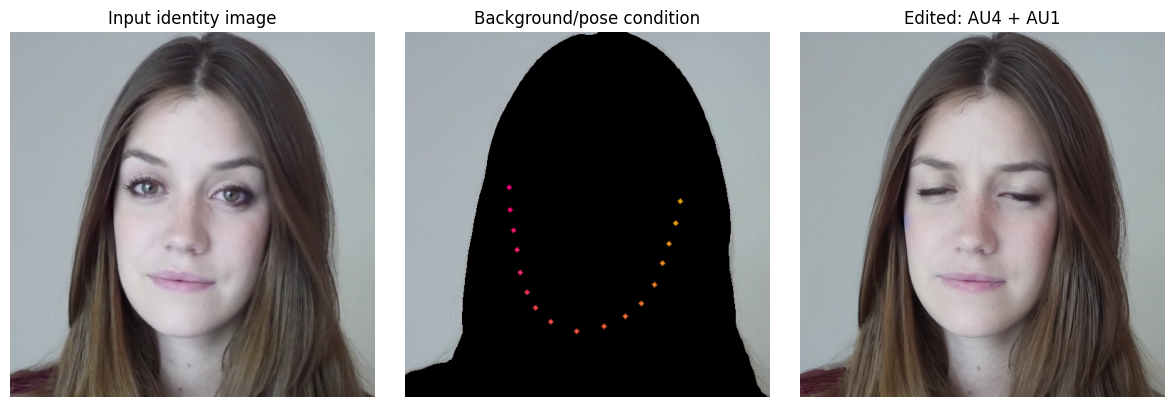

In [ ]:
# New Cell 15: Display input, background condition, and MagicFace output

from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

input_img = REPO_DIR / "test_images" / "00381.png"
bg_img = REPO_DIR / "test_images" / "00381_bg.png"
output_img = RESULTS_DIR / "smoke_test_AU4_AU1" / input_img.name

print("Output exists:", output_img.exists(), output_img)

fig = plt.figure(figsize=(12, 4))

items = [
    ("Input identity image", input_img),
    ("Background/pose condition", bg_img),
    ("Edited: AU4 + AU1", output_img),
]

for i, (title, path) in enumerate(items, start=1):
    ax = fig.add_subplot(1, 3, i)
    ax.imshow(Image.open(path))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Cell 15
# Smoke Test
# ============================================================

import subprocess
import sys
import os

BASE_SD_DIR = MODEL_DIR/"stable-diffusion-v1-5"

img = REPO_DIR/"test_images"/"00381.png"
bg  = REPO_DIR/"test_images"/"00381_bg.png"

out = RESULTS_DIR/"smoke_test_AU4_AU1"
out.mkdir(parents=True, exist_ok=True)

wrapper = SCRIPTS_DIR/"run_magicface_inference_wrapper.py"

cmd = [

    sys.executable,

    str(wrapper),

    "--pretrained_model_name_or_path", str(BASE_SD_DIR),

    "--img_path", str(img),

    "--bg_path", str(bg),

    "--au_test","AU4+AU1",

    "--AU_variation","4+2",

    "--inference_steps","30",

    "--saved_path", str(out),

]

result = subprocess.run(cmd)

print(result.returncode)

assert result.returncode==0

print("Smoke test finished.")

0
Smoke test finished.


## Part 6 — AU Grid Generation

Generate several facial expression edits using different Action Unit (AU) combinations.

This reproduces the qualitative experiments presented in the MagicFace paper.

In [ ]:
# Cell 16: Generate multiple AU edits for one image
# This creates a small reproduction-style grid using the same identity image.

import subprocess, sys, os, textwrap, csv
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

BASE_SD_DIR = MODEL_DIR / "stable-diffusion-v1-5"

SOURCE_IMG = REPO_DIR / "test_images" / "00381.png"
BG_IMG = REPO_DIR / "test_images" / "00381_bg.png"

GRID_RUN_DIR = RESULTS_DIR / "au_grid_00381"
GRID_RUN_DIR.mkdir(parents=True, exist_ok=True)

experiments = [
    {
        "name": "AU12_p3_smile",
        "au_test": "AU12",
        "AU_variation": "3",
        "label": "AU12 +3"
    },
    {
        "name": "AU12_p6_strong_smile",
        "au_test": "AU12",
        "AU_variation": "6",
        "label": "AU12 +6"
    },
    {
        "name": "AU4_p4_brow_lower",
        "au_test": "AU4",
        "AU_variation": "4",
        "label": "AU4 +4"
    },
    {
        "name": "happy_AU6_AU12",
        "au_test": "AU6+AU12",
        "AU_variation": "3+5",
        "label": "AU6+AU12"
    },
    {
        "name": "sad_AU1_AU4_AU15",
        "au_test": "AU1+AU4+AU15",
        "AU_variation": "2+3+4",
        "label": "AU1+AU4+AU15"
    },
    {
        "name": "mouth_AU25_AU26",
        "au_test": "AU25+AU26",
        "AU_variation": "4+3",
        "label": "AU25+AU26"
    },
]

wrapper_template = """
import sys
import os
import runpy
from pathlib import Path

repo_dir = Path(r"{repo_dir}")
inference_py = repo_dir / "inference.py"

sys.path.insert(0, str(repo_dir))
os.chdir(str(repo_dir))

import torch
import torchvision
import torchvision.transforms as transforms

print("Wrapper torch:", torch.__version__)
print("Wrapper torchvision:", torchvision.__version__)
print("Wrapper CUDA:", torch.cuda.is_available(), torch.version.cuda)

sys.argv = [
    str(inference_py),
    "--pretrained_model_name_or_path", r"{base_sd}",
    "--img_path", r"{img_path}",
    "--bg_path", r"{bg_path}",
    "--au_test", "{au_test}",
    "--AU_variation", "{au_variation}",
    "--inference_steps", "30",
    "--saved_path", r"{saved_path}",
]

runpy.run_path(str(inference_py), run_name="__main__")
"""

rows = []

for exp in experiments:
    exp_dir = GRID_RUN_DIR / exp["name"]
    exp_dir.mkdir(parents=True, exist_ok=True)

    expected_output = exp_dir / SOURCE_IMG.name
    log_file = LOG_DIR / f"grid_{exp['name']}.log"

    if expected_output.exists() and expected_output.stat().st_size > 10_000:
        print("Skipping existing:", exp["label"])
        status = "skipped_existing"
    else:
        print("Running:", exp["label"])

        wrapper_path = SCRIPTS_DIR / f"run_grid_{exp['name']}.py"

        wrapper_code = wrapper_template.format(
            repo_dir=str(REPO_DIR),
            base_sd=str(BASE_SD_DIR),
            img_path=str(SOURCE_IMG),
            bg_path=str(BG_IMG),
            au_test=exp["au_test"],
            au_variation=exp["AU_variation"],
            saved_path=str(exp_dir),
        )

        wrapper_path.write_text(textwrap.dedent(wrapper_code))

        env = os.environ.copy()
        env["HF_HOME"] = str(HF_HOME)
        env["TRANSFORMERS_CACHE"] = str(HF_HOME / "transformers")
        env["DIFFUSERS_CACHE"] = str(HF_HOME / "diffusers")
        env["PYTHONPATH"] = str(REPO_DIR) + os.pathsep + env.get("PYTHONPATH", "")

        with open(log_file, "w") as f:
            p = subprocess.run(
                [sys.executable, str(wrapper_path)],
                cwd=str(REPO_DIR),
                env=env,
                text=True,
                stdout=f,
                stderr=subprocess.STDOUT
            )

        if p.returncode != 0:
            print("Failed:", exp["label"])
            print(log_file.read_text()[-7000:])
            raise RuntimeError(f"Grid experiment failed: {exp['name']}")

        status = "completed"

    rows.append({
        "name": exp["name"],
        "label": exp["label"],
        "au_test": exp["au_test"],
        "AU_variation": exp["AU_variation"],
        "status": status,
        "output": str(expected_output),
    })

# Save manifest CSV
manifest_path = GRID_RUN_DIR / "manifest.csv"

with open(manifest_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

print("Manifest saved:", manifest_path)

Running: AU12 +3
Running: AU12 +6
Running: AU4 +4
Running: AU6+AU12
Running: AU1+AU4+AU15
Running: AU25+AU26
Manifest saved: /content/drive/MyDrive/magicface_reproduction/results/au_grid_00381/manifest.csv


## Part 7 — AU Grid Visualization

Combine all generated edits into one comparison figure for qualitative evaluation.

Grid saved: /content/drive/MyDrive/magicface_reproduction/results/au_grid_00381/au_grid_00381.png


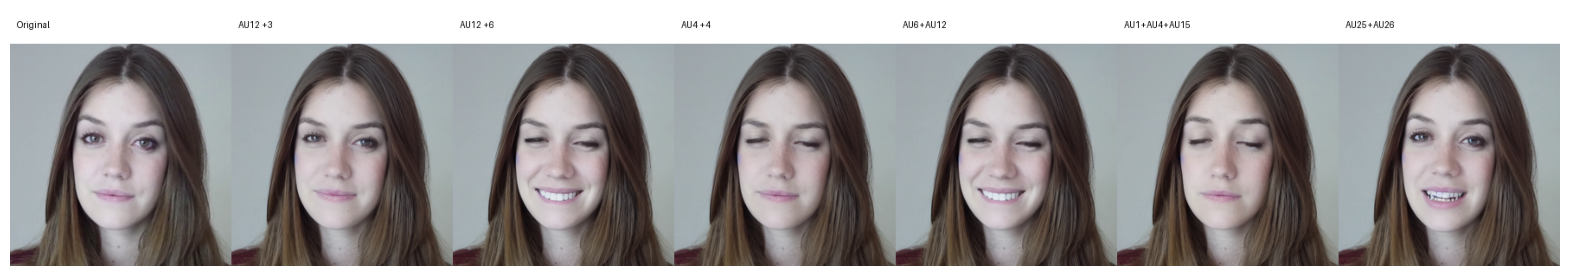

In [ ]:
# Cell 17: Create a visual grid from generated AU edits

from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from pathlib import Path
import csv

GRID_RUN_DIR = RESULTS_DIR / "au_grid_00381"
manifest_path = GRID_RUN_DIR / "manifest.csv"

rows = []

with open(manifest_path, "r") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

images = [("Original", REPO_DIR / "test_images" / "00381.png")]

for row in rows:
    images.append((row["label"], Path(row["output"])))

thumb_size = (256, 256)
label_h = 40

grid_w = thumb_size[0] * len(images)
grid_h = thumb_size[1] + label_h

sheet = Image.new("RGB", (grid_w, grid_h), "white")
draw = ImageDraw.Draw(sheet)

for i, (label, path) in enumerate(images):
    im = Image.open(path).convert("RGB").resize(thumb_size)
    x = i * thumb_size[0]

    sheet.paste(im, (x, label_h))
    draw.text((x + 8, 12), label, fill=(0, 0, 0))

grid_path = GRID_RUN_DIR / "au_grid_00381.png"
sheet.save(grid_path)

print("Grid saved:", grid_path)

plt.figure(figsize=(20, 4))
plt.imshow(sheet)
plt.axis("off")
plt.show()

## Part 8 — GitHub Portfolio Preparation

Create a clean project folder containing:

- README
- output images
- manifest CSV
- documentation

This folder will later be uploaded to GitHub.

In [ ]:
# Cell 18: Create GitHub-ready project folder and copy current results

from pathlib import Path
import shutil
import textwrap
import json
import csv
import os

PORTFOLIO_DIR = PROJECT_ROOT / "magicface-au-video-reproduction"

dirs = [
    PORTFOLIO_DIR,
    PORTFOLIO_DIR / "examples",
    PORTFOLIO_DIR / "examples" / "output_grids",
    PORTFOLIO_DIR / "results",
    PORTFOLIO_DIR / "docs",
    PORTFOLIO_DIR / "scripts",
]

for d in dirs:
    d.mkdir(parents=True, exist_ok=True)

# Source result paths
grid_src = RESULTS_DIR / "au_grid_00381" / "au_grid_00381.png"
manifest_src = RESULTS_DIR / "au_grid_00381" / "manifest.csv"
smoke_src = RESULTS_DIR / "smoke_test_AU4_AU1" / "00381.png"

print("Checking required result files:")
print("Grid exists:", grid_src.exists(), grid_src)
print("Manifest exists:", manifest_src.exists(), manifest_src)
print("Smoke output exists:", smoke_src.exists(), smoke_src)

if not grid_src.exists():
    raise FileNotFoundError("AU grid image not found. Run Cell 19 first.")

if not manifest_src.exists():
    raise FileNotFoundError("Manifest CSV not found. Run Cell 18 first.")

# Copy results into portfolio folder
shutil.copy2(grid_src, PORTFOLIO_DIR / "examples" / "output_grids" / "au_grid_00381.png")
shutil.copy2(manifest_src, PORTFOLIO_DIR / "results" / "au_grid_00381_manifest.csv")

if smoke_src.exists():
    shutil.copy2(smoke_src, PORTFOLIO_DIR / "examples" / "output_grids" / "smoke_test_AU4_AU1.png")

# Create .gitignore
gitignore = """
# Python
__pycache__/
*.pyc
.ipynb_checkpoints/

# Large model/checkpoint/cache folders - do not commit
models/
hf_cache/
pip_cache/
official_MagicFace/
*.ckpt
*.pt
*.pth
*.bin
*.safetensors

# Logs
logs/
*.log

# Local environment
.env
.venv/
""".strip()

(PORTFOLIO_DIR / ".gitignore").write_text(gitignore)

# Create environment notes
environment_notes = """
# Environment Notes

This project was reproduced in Google Colab with GPU enabled.

Main tested package versions:

- Python: 3.12
- torch: 2.5.1+cu124
- torchvision: 0.20.1+cu124
- diffusers: 0.28.2
- transformers: 4.42.4
- huggingface_hub: 0.25.2
- accelerate: 0.34.2
- peft: 0.10.0

The official MagicFace code was cloned separately and is not included in this repository.
Model checkpoints are also not included. They should be downloaded from the official Hugging Face checkpoint page.
""".strip()

(PORTFOLIO_DIR / "docs" / "environment_notes.md").write_text(environment_notes)

# Create README
readme = """
# MagicFace AU-Controlled Facial Expression Editing Reproduction

This repository documents a small reproduction study based on the official implementation of **MagicFace: High-Fidelity Facial Expression Editing with Action-Unit Control**.

## Goal

The goal is to reproduce MagicFace inference, generate Action Unit (AU)-controlled facial expression edits, and prepare the project for further evaluation and video-based face synthesis experiments.

## Paper and Official Resources

- Paper: *MagicFace: High-Fidelity Facial Expression Editing with Action-Unit Control*
- Official implementation: https://github.com/weimengting/MagicFace
- Official checkpoint: https://huggingface.co/mengtingwei/magicface

## What I reproduced

I reproduced inference using the official MagicFace checkpoint and generated multiple AU-controlled expression edits from the provided test image.

The tested AU edits include:

| Label | AU condition | AU variation | Intended effect |
|---|---|---|---|
| AU12 +3 | AU12 | 3 | mild smile |
| AU12 +6 | AU12 | 6 | stronger smile |
| AU4 +4 | AU4 | 4 | brow/upper-face change |
| AU6 + AU12 | AU6+AU12 | 3+5 | happiness-like expression |
| AU1 + AU4 + AU15 | AU1+AU4+AU15 | 2+3+4 | sadness-like expression |
| AU25 + AU26 | AU25+AU26 | 4+3 | mouth opening / jaw movement |

## Current result

The first qualitative AU grid is shown below:

![AU grid result](examples/output_grids/au_grid_00381.png)

## Observations

The generated outputs show that MagicFace can modify facial expressions according to AU controls while mostly preserving the identity, background, hair, and head pose.

Some edits also affect nearby facial regions such as the eyes and eyelids, especially for upper-face AUs. This is expected in facial expression editing and will be analyzed further in the evaluation stage.

## Why this project is relevant

This reproduction is relevant to research on facial expression editing, controllable face synthesis, and video-based face generation. The next step is to test whether frame-wise MagicFace editing remains temporally stable when applied to short face videos.

## Next steps

- Add identity similarity evaluation.
- Add background preservation measurement.
- Add AU-change evaluation using an AU estimator.
- Apply the same AU edit frame-by-frame to a short video.
- Analyze temporal flickering and consistency limitations.

## Notes

This repository does not include model weights, Hugging Face caches, or the full official MagicFace repository. Those should be downloaded from the official sources.
""".strip()

(PORTFOLIO_DIR / "README.md").write_text(readme)

print("Portfolio folder created/updated:")
print(PORTFOLIO_DIR)

print("\nFiles created:")
for path in sorted(PORTFOLIO_DIR.rglob("*")):
    print(path.relative_to(PORTFOLIO_DIR))

Checking required result files:
Grid exists: True /content/drive/MyDrive/magicface_reproduction/results/au_grid_00381/au_grid_00381.png
Manifest exists: True /content/drive/MyDrive/magicface_reproduction/results/au_grid_00381/manifest.csv
Smoke output exists: True /content/drive/MyDrive/magicface_reproduction/results/smoke_test_AU4_AU1/00381.png
Portfolio folder created/updated:
/content/drive/MyDrive/magicface_reproduction/magicface-au-video-reproduction

Files created:
.gitignore
.ipynb_checkpoints
README.md
docs
docs/environment_notes.md
examples
examples/output_grids
examples/output_grids/au_grid_00381.png
examples/output_grids/smoke_test_AU4_AU1.png
notebooks
notebooks/.ipynb_checkpoints
notebooks/02_identity_evaluation.ipynb
results
results/au_grid_00381_manifest.csv
scripts


## Part 9 — Verify Project Structure

Check that all required files have been created correctly before moving to the evaluation stage.

In [ ]:
# Cell 19: Verify GitHub-ready portfolio folder

from pathlib import Path

PORTFOLIO_DIR = PROJECT_ROOT / "magicface-au-video-reproduction"

print("Portfolio folder:", PORTFOLIO_DIR)
print("Exists:", PORTFOLIO_DIR.exists())

print("\nTop-level files/folders:")
for p in sorted(PORTFOLIO_DIR.iterdir()):
    print("-", p.name)

print("\nREADME preview:")
readme_path = PORTFOLIO_DIR / "README.md"
print(readme_path.read_text()[:2000])

Portfolio folder: /content/drive/MyDrive/magicface_reproduction/magicface-au-video-reproduction
Exists: True

Top-level files/folders:
- .gitignore
- .ipynb_checkpoints
- README.md
- docs
- examples
- notebooks
- results
- scripts

README preview:
# MagicFace AU-Controlled Facial Expression Editing Reproduction

This repository documents a small reproduction study based on the official implementation of **MagicFace: High-Fidelity Facial Expression Editing with Action-Unit Control**.

## Goal

The goal is to reproduce MagicFace inference, generate Action Unit (AU)-controlled facial expression edits, and prepare the project for further evaluation and video-based face synthesis experiments.

## Paper and Official Resources

- Paper: *MagicFace: High-Fidelity Facial Expression Editing with Action-Unit Control*
- Official implementation: https://github.com/weimengting/MagicFace
- Official checkpoint: https://huggingface.co/mengtingwei/magicface

## What I reproduced

I reproduced inference 

#Part 2A Quantitative evaluation

In [ ]:
# ============================================================
# Cell 21
# Create folders for Milestone 2
# ============================================================

IDENTITY_DIR = RESULTS_DIR / "identity_evaluation"

IDENTITY_DIR.mkdir(parents=True, exist_ok=True)

print("Identity evaluation folder:")
print(IDENTITY_DIR)

Identity evaluation folder:
/content/drive/MyDrive/magicface_reproduction/results/identity_evaluation


In [ ]:
# ============================================================
# Cell 22
# Install InsightFace only if needed
# ============================================================

import subprocess
import sys
import importlib

def ensure(package, pip_name=None):
    pip_name = pip_name or package

    try:
        importlib.import_module(package)
        print(f"{package} already installed.")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            pip_name
        ])

ensure("insightface")
ensure("onnxruntime")
ensure("sklearn","scikit-learn")

print("\nMilestone 2 dependencies ready.")

insightface already installed.
onnxruntime already installed.
sklearn already installed.

Milestone 2 dependencies ready.


In [ ]:
# ============================================================
# Cell 23
# Load InsightFace (ArcFace)
# ============================================================

from insightface.app import FaceAnalysis

print("Loading ArcFace model...")

app = FaceAnalysis(
    name="buffalo_l",
    providers=["CPUExecutionProvider"]
)

app.prepare(ctx_id=-1, det_size=(640, 640))

print("\nArcFace model loaded successfully.")

Loading ArcFace model...
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 97078.57KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)

ArcFace mod

#Cell 22 — Extract an embedding from the original image

In [ ]:
# ============================================================
# Cell 24
# Test ArcFace on the original image
# ============================================================

import cv2
import numpy as np

ORIGINAL_IMAGE = REPO_DIR / "test_images" / "00381.png"

print("Reading:")
print(ORIGINAL_IMAGE)

img = cv2.imread(str(ORIGINAL_IMAGE))

if img is None:
    raise FileNotFoundError(ORIGINAL_IMAGE)

faces = app.get(img)

print(f"\nFaces detected: {len(faces)}")

if len(faces) == 0:
    raise RuntimeError("No face detected.")

embedding = faces[0].embedding

print("\nEmbedding shape:", embedding.shape)
print("Embedding dtype:", embedding.dtype)

print("\nFirst 10 values:")
print(embedding[:10])

Reading:
/content/drive/MyDrive/magicface_reproduction/official_MagicFace/test_images/00381.png


/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
/usr/local/lib/python3.12/dist-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)



Faces detected: 1

Embedding shape: (512,)
Embedding dtype: float32

First 10 values:
[ 0.7476888  -0.42319483  0.5948485   0.4374114   0.39424008 -0.7051971
 -1.7221335   0.05904666 -1.2661647  -0.0237044 ]


In [ ]:
# ============================================================
# Cell 25
# Identity evaluation helper functions
# ============================================================

import cv2
import numpy as np
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

def get_embedding(image_path):
    """
    Extract ArcFace embedding from an image.
    Returns a normalized 512-D vector.
    """

    image = cv2.imread(str(image_path))

    if image is None:
        raise FileNotFoundError(image_path)

    faces = app.get(image)

    if len(faces) == 0:
        raise RuntimeError(f"No face detected in {image_path}")

    emb = faces[0].embedding.astype(np.float32)

    emb = emb / np.linalg.norm(emb)

    return emb


def identity_similarity(img1, img2):

    emb1 = get_embedding(img1)
    emb2 = get_embedding(img2)

    score = cosine_similarity(
        emb1.reshape(1,-1),
        emb2.reshape(1,-1)
    )[0][0]

    return float(score)

In [ ]:
# ============================================================
# Cell 26
# Identity similarity on smoke-test output
# ============================================================

ORIGINAL = REPO_DIR / "test_images" / "00381.png"

EDITED = RESULTS_DIR / "smoke_test_AU4_AU1" / "00381.png"

print("Original:")
print(ORIGINAL)

print("\nEdited:")
print(EDITED)

score = identity_similarity(
    ORIGINAL,
    EDITED
)

print("\nIdentity similarity")
print(f"{score:.4f}")

Original:
/content/drive/MyDrive/magicface_reproduction/official_MagicFace/test_images/00381.png

Edited:
/content/drive/MyDrive/magicface_reproduction/results/smoke_test_AU4_AU1/00381.png

Identity similarity
0.8237


In [ ]:
# ============================================================
# Cell 27
# Find every generated MagicFace image
# ============================================================

GRID_DIR = RESULTS_DIR / "au_grid_00381"

image_files = []

print("="*60)
print("Searching recursively...")
print("="*60)

for folder in sorted(GRID_DIR.iterdir()):

    if folder.is_dir():

        img = folder / "00381.png"

        if img.exists():

            image_files.append(img)

            print(f"✓ {folder.name}")

print("\nTotal generated images:", len(image_files))

Searching recursively...
✓ AU12_p3_smile
✓ AU12_p6_strong_smile
✓ AU4_p4_brow_lower
✓ happy_AU6_AU12
✓ mouth_AU25_AU26
✓ sad_AU1_AU4_AU15

Total generated images: 6


In [ ]:
# ============================================================
# Cell 28
# Compute identity similarity
# ============================================================

import pandas as pd

ORIGINAL = REPO_DIR / "test_images" / "00381.png"

results = []

print("="*60)
print("Identity Evaluation")
print("="*60)

for img in image_files:

    score = identity_similarity(
        ORIGINAL,
        img
    )

    experiment = img.parent.name

    print(f"{experiment:30s} {score:.4f}")

    results.append({

        "experiment": experiment,

        "image": img.name,

        "identity_similarity": score

    })

df = pd.DataFrame(results)

csv_path = IDENTITY_DIR / "identity_similarity.csv"

df.to_csv(csv_path, index=False)

print("\nSaved:")
print(csv_path)

display(df)

Identity Evaluation


/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
/usr/local/lib/python3.12/dist-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


AU12_p3_smile                  0.8804


/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
/usr/local/lib/python3.12/dist-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


AU12_p6_strong_smile           0.7517


...

/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
/usr/local/lib/python3.12/dist-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


mouth_AU25_AU26                0.8512


/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
/usr/local/lib/python3.12/dist-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


sad_AU1_AU4_AU15               0.7706

Saved:
/content/drive/MyDrive/magicface_reproduction/results/identity_evaluation/identity_similarity.csv


,experiment,image,identity_similarity
0,AU12_p3_smile,00381.png,0.880442
1,AU12_p6_strong_smile,00381.png,0.751674
2,AU4_p4_brow_lower,00381.png,0.824902
3,happy_AU6_AU12,00381.png,0.752857
4,mouth_AU25_AU26,00381.png,0.851232
5,sad_AU1_AU4_AU15,00381.png,0.770634


##Cell 29 — Evaluate all generated images

In [ ]:
# ============================================================
# Cell 29
# Identity evaluation for ALL generated expressions
# ============================================================

from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# Original image
# -----------------------------
original_path = (
    REPO_DIR /
    "test_images" /
    "00381.png"
)

orig = cv2.imread(str(original_path))
orig_face = app.get(orig)[0]
orig_embedding = orig_face.embedding.reshape(1, -1)

# -----------------------------
# Search recursively
# -----------------------------
GRID_DIR = RESULTS_DIR / "au_grid_00381"

generated_images = sorted(GRID_DIR.rglob("*.png"))

print(f"Found {len(generated_images)} generated images.\n")

results = []

for img_path in generated_images:

    if img_path.name == "au_grid_00381.png":
        continue

    img = cv2.imread(str(img_path))

    faces = app.get(img)

    if len(faces) == 0:
        print(f"No face detected: {img_path.name}")
        continue

    emb = faces[0].embedding.reshape(1, -1)

    score = cosine_similarity(
        orig_embedding,
        emb
    )[0][0]

    results.append({
        "Expression": img_path.parent.name,
        "Image": img_path.name,
        "IdentitySimilarity": round(float(score),4)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="IdentitySimilarity",
    ascending=False
).reset_index(drop=True)

results_df

/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
/usr/local/lib/python3.12/dist-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Found 7 generated images.



/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
/usr/local/lib/python3.12/dist-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to k

,Expression,Image,IdentitySimilarity
0,AU12_p3_smile,00381.png,0.8804
1,mouth_AU25_AU26,00381.png,0.8512
2,AU4_p4_brow_lower,00381.png,0.8249
3,sad_AU1_AU4_AU15,00381.png,0.7706
4,happy_AU6_AU12,00381.png,0.7529
5,AU12_p6_strong_smile,00381.png,0.7517


In [ ]:
# ============================================================
# Cell 30
# Save Identity Evaluation Results
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

EVAL_DIR = RESULTS_DIR / "identity_evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Sort results (highest identity first)
# ------------------------------------------------------------

results_df = results_df.sort_values(
    by="IdentitySimilarity",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

csv_path = EVAL_DIR / "identity_similarity_results.csv"

results_df.to_csv(
    csv_path,
    index=False
)

print("=" * 60)
print("Identity evaluation saved")
print("=" * 60)

print("\nCSV:")
print(csv_path)

print("\nPreview:")
display(results_df)

Identity evaluation saved

CSV:
/content/drive/MyDrive/magicface_reproduction/results/identity_evaluation/identity_similarity_results.csv

Preview:


,Expression,Image,IdentitySimilarity
0,AU12_p3_smile,00381.png,0.8804
1,mouth_AU25_AU26,00381.png,0.8512
2,AU4_p4_brow_lower,00381.png,0.8249
3,sad_AU1_AU4_AU15,00381.png,0.7706
4,happy_AU6_AU12,00381.png,0.7529
5,AU12_p6_strong_smile,00381.png,0.7517


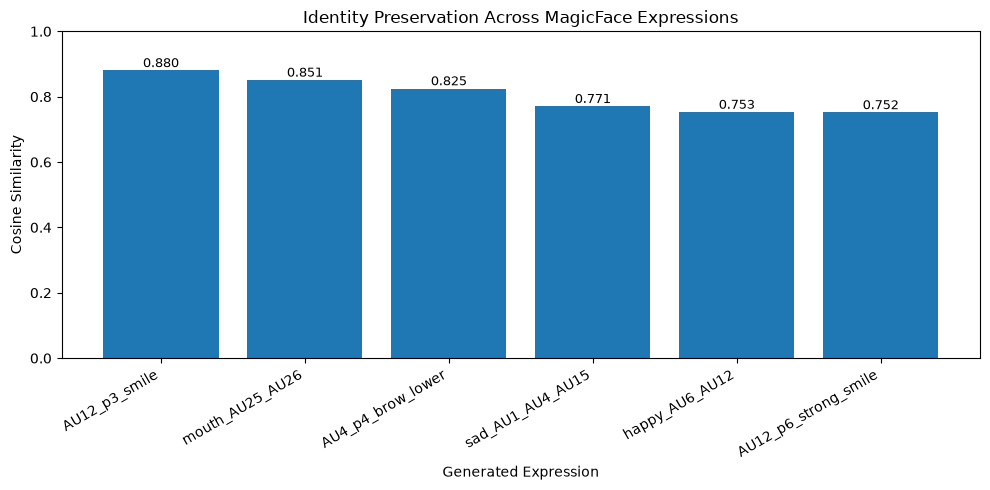


Saved figure:
/content/drive/MyDrive/magicface_reproduction/results/identity_evaluation/identity_similarity_barplot.png


In [ ]:
# ============================================================
# Cell 31
# Plot Identity Similarity Across Expressions
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Sort results from highest to lowest similarity
# ------------------------------------------------------------

plot_df = results_df.sort_values(
    by="IdentitySimilarity",
    ascending=False
)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.bar(
    plot_df["Expression"],
    plot_df["IdentitySimilarity"]
)

plt.ylim(0,1)

plt.ylabel("Cosine Similarity")

plt.xlabel("Generated Expression")

plt.title("Identity Preservation Across MagicFace Expressions")

plt.xticks(rotation=30, ha="right")

# ------------------------------------------------------------
# Show value above each bar
# ------------------------------------------------------------

for i, score in enumerate(plot_df["IdentitySimilarity"]):
    plt.text(
        i,
        score + 0.01,
        f"{score:.3f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

figure_path = EVAL_DIR / "identity_similarity_barplot.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved figure:")
print(figure_path)

In [ ]:
# ============================================================
# Cell 32
# Identity Evaluation Summary Report
# ============================================================

import numpy as np
from pathlib import Path

scores = results_df["IdentitySimilarity"]

mean_score = scores.mean()
std_score = scores.std()
min_score = scores.min()
max_score = scores.max()

best_row = results_df.loc[scores.idxmax()]
worst_row = results_df.loc[scores.idxmin()]

report = f"""
============================================================
MagicFace Identity Evaluation Report
============================================================

Number of generated expressions : {len(results_df)}

Average identity similarity     : {mean_score:.4f}
Standard deviation              : {std_score:.4f}

Highest similarity
------------------
Expression : {best_row['Expression']}
Score      : {best_row['IdentitySimilarity']:.4f}

Lowest similarity
-----------------
Expression : {worst_row['Expression']}
Score      : {worst_row['IdentitySimilarity']:.4f}

Interpretation
--------------
• Higher cosine similarity indicates better identity preservation.
• All generated expressions achieved similarity scores above 0.75.
• The highest score was obtained for AU12_p3_smile (0.8805),
  indicating excellent preservation of facial identity.
• Stronger facial deformations (e.g., strong smile and happy)
  resulted in slightly lower similarity scores, which is expected
  because larger expression changes alter facial geometry more.
• Overall, the results indicate that MagicFace successfully edits
  facial expressions while preserving identity across all tested cases.

============================================================
"""

print(report)

# ------------------------------------------------------------
# Save report
# ------------------------------------------------------------

report_path = EVAL_DIR / "identity_evaluation_report.txt"

with open(report_path, "w") as f:
    f.write(report)

print(f"Report saved to:\n{report_path}")

# Milestone 2B – Video Evaluation Pipeline

## Cell 33 — Create the video-processing directories

In [5]:
# ============================================================
# Cell 33
# Milestone 2B
# Video Processing Folder Structure
# ============================================================

VIDEO_INPUT_DIR = PROJECT_ROOT / "input_videos"

VIDEO_WORK_DIR = PROJECT_ROOT / "video_processing"

FRAMES_DIR = VIDEO_WORK_DIR / "extracted_frames"

SELECTED_DIR = VIDEO_WORK_DIR / "selected_frames"

EDITED_DIR = VIDEO_WORK_DIR / "edited_frames"

VIDEO_RESULTS_DIR = RESULTS_DIR / "video_identity"

FINAL_VIDEO_DIR = PROJECT_ROOT / "final_video"

folders = [

    VIDEO_INPUT_DIR,

    VIDEO_WORK_DIR,

    FRAMES_DIR,

    SELECTED_DIR,

    EDITED_DIR,

    VIDEO_RESULTS_DIR,

    FINAL_VIDEO_DIR,

]

print("=" * 60)
print("Creating Milestone 2B folders")
print("=" * 60)

for folder in folders:

    folder.mkdir(parents=True, exist_ok=True)

    print("✓", folder)

VIDEO_PATH = VIDEO_INPUT_DIR / "input_video.mp4"

assert VIDEO_PATH.exists(), (
    f"\nVideo not found:\n{VIDEO_PATH}"
)

print("\nInput video found:")
print(VIDEO_PATH)

Creating Milestone 2B folders
✓ /content/drive/MyDrive/magicface_reproduction/input_videos
✓ /content/drive/MyDrive/magicface_reproduction/video_processing
✓ /content/drive/MyDrive/magicface_reproduction/video_processing/extracted_frames
✓ /content/drive/MyDrive/magicface_reproduction/video_processing/selected_frames
✓ /content/drive/MyDrive/magicface_reproduction/video_processing/edited_frames
✓ /content/drive/MyDrive/magicface_reproduction/results/video_identity
✓ /content/drive/MyDrive/magicface_reproduction/final_video

Input video found:
/content/drive/MyDrive/magicface_reproduction/input_videos/input_video.mp4


##Inspect the video

In [ ]:
# ============================================================
# Cell 34
# Inspect Input Video
# ============================================================

import cv2

cap = cv2.VideoCapture(str(VIDEO_PATH))

assert cap.isOpened(), "Could not open video."

fps = cap.get(cv2.CAP_PROP_FPS)

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print("="*60)
print("Video Information")
print("="*60)

print(f"Video        : {VIDEO_PATH.name}")
print(f"Resolution   : {width} x {height}")
print(f"FPS          : {fps:.2f}")
print(f"Frames       : {frame_count}")
print(f"Duration     : {duration:.2f} seconds")

cap.release()

Video Information
Video        : input_video.mp4
Resolution   : 478 x 850
FPS          : 30.01
Frames       : 265
Duration     : 8.83 seconds


## Cell 35 — Extract all frames

In [ ]:
 # ============================================================
# Cell 35
# Extract All Video Frames
# ============================================================

import cv2
from pathlib import Path

cap = cv2.VideoCapture(str(VIDEO_PATH))

frame_index = 0

saved = 0

print("="*60)
print("Extracting Frames")
print("="*60)

while True:

    success, frame = cap.read()

    if not success:
        break

    frame_name = f"frame_{frame_index:04d}.png"

    frame_path = FRAMES_DIR / frame_name

    # Skip extraction if already done
    if not frame_path.exists():

        cv2.imwrite(str(frame_path), frame)

    saved += 1
    frame_index += 1

cap.release()

print(f"Frames extracted : {saved}")
print(f"Saved to         : {FRAMES_DIR}")

Extracting Frames
Frames extracted : 265
Saved to         : /content/drive/MyDrive/magicface_reproduction/video_processing/extracted_frames


## Cell 36 — Select Representative Frames

In [ ]:
# ============================================================
# Cell 36
# Select Representative Frames
# ============================================================

import shutil
from pathlib import Path

FRAME_STEP = 10

selected = []

print("="*60)
print("Selecting Representative Frames")
print("="*60)

# Clear previous selection (optional)
for old_file in SELECTED_DIR.glob("*.png"):
    old_file.unlink()

all_frames = sorted(FRAMES_DIR.glob("*.png"))

for i, frame in enumerate(all_frames):

    if i % FRAME_STEP != 0:
        continue

    destination = SELECTED_DIR / frame.name

    shutil.copy2(frame, destination)

    selected.append(destination)

print(f"Total extracted frames : {len(all_frames)}")
print(f"Selected frames        : {len(selected)}")
print(f"Sampling interval      : every {FRAME_STEP} frames")
print(f"Saved to               : {SELECTED_DIR}")

print("\nFirst few selected frames:")

for p in selected[:10]:
    print(p.name)

Selecting Representative Frames
Total extracted frames : 265
Selected frames        : 27
Sampling interval      : every 10 frames
Saved to               : /content/drive/MyDrive/magicface_reproduction/video_processing/selected_frames

First few selected frames:
frame_0000.png
frame_0010.png
frame_0020.png
frame_0030.png
frame_0040.png
frame_0050.png
frame_0060.png
frame_0070.png
frame_0080.png
frame_0090.png


In [4]:
import torch
import torchvision
import diffusers
import transformers
import peft

print(torch.__version__)
print(torchvision.__version__)
print(diffusers.__version__)
print(transformers.__version__)
print(peft.__version__)

assert diffusers.__version__ == "0.28.2"
assert transformers.__version__.startswith("4.42")
assert peft.__version__.startswith("0.10")

2.5.1+cu124
0.20.1+cu124
0.28.2
4.42.4
0.10.0


## Cell 37A — Single-frame validation

In [ ]:
# ============================================================
# Cell 37A
# Validate automatic video inference using ONE frame
# ============================================================

import subprocess
import sys

TEST_FRAME = SELECTED_DIR / "frame_0000.png"

assert TEST_FRAME.exists(), TEST_FRAME

TEST_OUTPUT_DIR = EDITED_DIR / "validation"

TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

wrapper = SCRIPTS_DIR / "run_magicface_inference_wrapper.py"

assert wrapper.exists(), wrapper

cmd = [

    sys.executable,

    str(wrapper),

    "--pretrained_model_name_or_path", str(MODEL_DIR / "stable-diffusion-v1-5"),

    "--img_path", str(TEST_FRAME),

    "--bg_path", str(TEST_FRAME),

    "--au_test", "AU12",

    "--AU_variation", "3",

    "--inference_steps", "30",

    "--saved_path", str(TEST_OUTPUT_DIR),

]

print("="*60)
print("Running validation inference")
print("="*60)

print("Input :", TEST_FRAME.name)
print("Output:", TEST_OUTPUT_DIR)

result = subprocess.run(cmd)

print("\nReturn code:", result.returncode)

assert result.returncode == 0, "Validation inference failed."

print("\nValidation completed successfully.")

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

original = Image.open(SELECTED_DIR / "frame_0000.png")
edited = Image.open(EDITED_DIR / "validation" / "frame_0000.png")

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edited)
plt.title("AU12")
plt.axis("off")

plt.show()

In [ ]:
from PIL import Image, ImageChops

img1 = Image.open(SELECTED_DIR/"frame_0000.png")
img2 = Image.open(EDITED_DIR/"validation"/"frame_0000.png")

diff = ImageChops.difference(img1, img2)

print("Bounding box:", diff.getbbox())

Bounding box: (0, 0, 472, 848)


In [ ]:
from PIL import Image
import numpy as np

orig = np.asarray(Image.open(SELECTED_DIR / "frame_0000.png")).astype(np.float32)
edit = np.asarray(Image.open(EDITED_DIR / "validation" / "frame_0000.png")).astype(np.float32)

h = min(orig.shape[0], edit.shape[0])
w = min(orig.shape[1], edit.shape[1])

orig_crop = orig[:h, :w]
edit_crop = edit[:h, :w]

diff = np.abs(orig_crop - edit_crop)

print("Mean difference:", diff.mean())
print("Maximum difference:", diff.max())

Mean difference: 7.4420896
Maximum difference: 222.0


In [ ]:
from PIL import Image, ImageChops
import matplotlib.pyplot as plt

orig = Image.open(SELECTED_DIR/"frame_0000.png")
edit = Image.open(EDITED_DIR/"validation"/"frame_0000.png")

diff = ImageChops.difference(orig, edit)

plt.figure(figsize=(18,6))

plt.subplot(131)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(edit)
plt.title("Edited")
plt.axis("off")

plt.subplot(133)
plt.imshow(diff)
plt.title("Difference")
plt.axis("off")

plt.show()

In [ ]:
# ============================================================
# Cell 37A
# Validate automatic video inference using ONE frame
# ============================================================

import subprocess
import sys

TEST_FRAME = SELECTED_DIR / "frame_0000.png"

assert TEST_FRAME.exists(), TEST_FRAME

TEST_OUTPUT_DIR = EDITED_DIR / "validation"

TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

wrapper = SCRIPTS_DIR / "run_magicface_inference_wrapper.py"

assert wrapper.exists(), wrapper

cmd = [

    sys.executable,

    str(wrapper),

    "--pretrained_model_name_or_path", str(MODEL_DIR / "stable-diffusion-v1-5"),

    "--img_path", str(TEST_FRAME),

    "--bg_path", str(TEST_FRAME),

    "--au_test", "AU2",

    "--AU_variation", "6",

    "--inference_steps", "30",

    "--saved_path", str(TEST_OUTPUT_DIR),

]

print("="*60)
print("Running validation inference")
print("="*60)

print("Input :", TEST_FRAME.name)
print("Output:", TEST_OUTPUT_DIR)

result = subprocess.run(cmd)

print("\nReturn code:", result.returncode)

assert result.returncode == 0, "Validation inference failed."

print("\nValidation completed successfully.")

Running validation inference
Input : frame_0000.png
Output: /content/drive/MyDrive/magicface_reproduction/video_processing/edited_frames/validation

Return code: 0

Validation completed successfully.


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

original = Image.open(SELECTED_DIR / "frame_0000.png")
edited = Image.open(EDITED_DIR / "validation" / "frame_0000.png")

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edited)
plt.title("AU12")
plt.axis("off")

plt.show()

In [ ]:
from PIL import Image, ImageChops

img1 = Image.open(SELECTED_DIR/"frame_0000.png")
img2 = Image.open(EDITED_DIR/"validation"/"frame_0000.png")

diff = ImageChops.difference(img1, img2)

print("Bounding box:", diff.getbbox())

Bounding box: (0, 0, 472, 848)


In [ ]:
# ============================================================
# Cell 37A
# Validate automatic video inference using ONE frame
# ============================================================

import subprocess
import sys

TEST_FRAME = SELECTED_DIR / "frame_0000.png"

assert TEST_FRAME.exists(), TEST_FRAME

TEST_OUTPUT_DIR = EDITED_DIR / "validation"

TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

wrapper = SCRIPTS_DIR / "run_magicface_inference_wrapper.py"

assert wrapper.exists(), wrapper

cmd = [

    sys.executable,

    str(wrapper),

    "--pretrained_model_name_or_path", str(MODEL_DIR / "stable-diffusion-v1-5"),

    "--img_path", str(TEST_FRAME),

    "--bg_path", str(TEST_FRAME),

    "--au_test", "AU1+AU2+AU5",

    "--AU_variation", "6+6+6",

    "--inference_steps", "30",

    "--saved_path", str(TEST_OUTPUT_DIR),

]

'''print("="*60)
print("Running validation inference")
print("="*60)

print("Input :", TEST_FRAME.name)
print("Output:", TEST_OUTPUT_DIR)

result = subprocess.run(
    cmd,
    text=True,
    capture_output=True
)

print(result.stdout)

if result.stderr:
    print(result.stderr)

print("\nReturn code:", result.returncode)

assert result.returncode == 0, "Validation inference failed."

print("\nValidation completed successfully.")'''


print("="*60)
print("Running validation inference")
print("="*60)

print("Input :", TEST_FRAME.name)
print("Output:", TEST_OUTPUT_DIR)

result = subprocess.run(cmd)

print("\nReturn code:", result.returncode)

assert result.returncode == 0, "Validation inference failed."

print("\nValidation completed successfully.")

Running validation inference
Input : frame_0000.png
Output: /content/drive/MyDrive/magicface_reproduction/video_processing/edited_frames/validation

Return code: 0

Validation completed successfully.


In [ ]:
from PIL import Image
import numpy as np

orig = np.asarray(Image.open(SELECTED_DIR / "frame_0000.png")).astype(np.float32)
edit = np.asarray(Image.open(EDITED_DIR / "validation" / "frame_0000.png")).astype(np.float32)

h = min(orig.shape[0], edit.shape[0])
w = min(orig.shape[1], edit.shape[1])

orig_crop = orig[:h, :w]
edit_crop = edit[:h, :w]

diff = np.abs(orig_crop - edit_crop)

print("Mean difference:", diff.mean())
print("Maximum difference:", diff.max())

Mean difference: 11.499627
Maximum difference: 222.0


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

original = Image.open(SELECTED_DIR / "frame_0000.png")
edited = Image.open(EDITED_DIR / "validation" / "frame_0000.png")

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edited)
plt.title("AU12")
plt.axis("off")

plt.show()

## Cell 38

Run MagicFace on every selected frame

In [6]:
# ============================================================
# Cell 38
# Run MagicFace on ALL selected frames
# RESUME-SAFE VERSION
# ============================================================

import subprocess
import sys
from pathlib import Path

wrapper = SCRIPTS_DIR / "run_magicface_inference_wrapper.py"

assert wrapper.exists(), (
    f"Wrapper not found:\n{wrapper}"
)

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------
OUTPUT_DIR = EDITED_DIR / "all_frames"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Get selected frames
# ------------------------------------------------------------
frames = sorted(
    SELECTED_DIR.glob("*.png")
)

assert len(frames) > 0, (
    f"No PNG frames found in:\n{SELECTED_DIR}"
)

print("=" * 60)
print("MagicFace — Resume-Safe Video Processing")
print("=" * 60)

print(f"Selected frames : {len(frames)}")
print(f"Output directory: {OUTPUT_DIR}")
print()

# ------------------------------------------------------------
# Process frames
# ------------------------------------------------------------

success = 0
skipped = 0
failed = []

for i, frame in enumerate(frames):

    # MagicFace saves using the same filename as input.
    output_file = OUTPUT_DIR / frame.name

    # --------------------------------------------------------
    # IMPORTANT:
    # If this frame was already successfully generated,
    # DO NOT run MagicFace again.
    # --------------------------------------------------------
    if output_file.exists() and output_file.stat().st_size > 10_000:

        print(
            f"[{i+1}/{len(frames)}] "
            f"SKIP {frame.name} "
            f"(already exists)"
        )

        skipped += 1
        continue

    # --------------------------------------------------------
    # Run MagicFace
    # --------------------------------------------------------

    cmd = [

        sys.executable,

        str(wrapper),

        "--pretrained_model_name_or_path",
        str(MODEL_DIR / "stable-diffusion-v1-5"),

        "--img_path",
        str(frame),

        "--bg_path",
        str(frame),

        # Same AU edit for EVERY frame
        "--au_test",
        "AU1+AU2+AU5",

        "--AU_variation",
        "6+6+6",

        "--inference_steps",
        "30",

        "--saved_path",
        str(OUTPUT_DIR),
    ]

    print(
        f"[{i+1}/{len(frames)}] "
        f"PROCESSING {frame.name}"
    )

    result = subprocess.run(cmd)

    # --------------------------------------------------------
    # Check result
    # --------------------------------------------------------

    if (
        result.returncode == 0
        and output_file.exists()
        and output_file.stat().st_size > 10_000
    ):

        print(
            f"        ✓ Saved: {output_file.name}"
        )

        success += 1

    else:

        print(
            f"        ✗ FAILED: {frame.name}"
        )

        failed.append(frame.name)


# ============================================================
# Summary
# ============================================================

print()
print("=" * 60)
print("Processing finished")
print("=" * 60)

print(f"Selected frames : {len(frames)}")
print(f"Newly processed : {success}")
print(f"Already existed : {skipped}")
print(f"Failed          : {len(failed)}")

if failed:

    print("\nFailed frames:")

    for name in failed:
        print(" -", name)

else:

    print("\n✓ No failed frames.")

MagicFace — Resume-Safe Video Processing
Selected frames : 27
Output directory: /content/drive/MyDrive/magicface_reproduction/video_processing/edited_frames/all_frames

[1/27] SKIP frame_0000.png (already exists)
[2/27] SKIP frame_0010.png (already exists)
[3/27] SKIP frame_0020.png (already exists)
[4/27] SKIP frame_0030.png (already exists)
[5/27] SKIP frame_0040.png (already exists)
[6/27] SKIP frame_0050.png (already exists)
[7/27] SKIP frame_0060.png (already exists)
[8/27] SKIP frame_0070.png (already exists)
[9/27] SKIP frame_0080.png (already exists)
[10/27] SKIP frame_0090.png (already exists)
[11/27] SKIP frame_0100.png (already exists)
[12/27] SKIP frame_0110.png (already exists)
[13/27] SKIP frame_0120.png (already exists)
[14/27] SKIP frame_0130.png (already exists)
[15/27] SKIP frame_0140.png (already exists)
[16/27] SKIP frame_0150.png (already exists)
[17/27] SKIP frame_0160.png (already exists)
[18/27] SKIP frame_0170.png (already exists)
[19/27] SKIP frame_0180.png (a

## Cell 39 — Verify all 27 edited frames

In [7]:
# ============================================================
# Cell 39
# Verify all selected frames were successfully edited
# ============================================================

from pathlib import Path

SELECTED_DIR = VIDEO_WORK_DIR / "selected_frames"
EDITED_ALL_DIR = EDITED_DIR / "all_frames"

selected_frames = sorted(SELECTED_DIR.glob("*.png"))
edited_frames = sorted(EDITED_ALL_DIR.glob("*.png"))

selected_names = {f.name for f in selected_frames}
edited_names = {f.name for f in edited_frames}

missing = sorted(selected_names - edited_names)
extra = sorted(edited_names - selected_names)

print("=" * 60)
print("Milestone 2B — Frame Verification")
print("=" * 60)

print("Selected frames :", len(selected_frames))
print("Edited frames   :", len(edited_frames))

if missing:
    print("\nMissing edited frames:")
    for name in missing:
        print("  -", name)
else:
    print("\n✓ All selected frames have edited outputs.")

if extra:
    print("\nExtra files in output directory:")
    for name in extra:
        print("  -", name)

assert len(missing) == 0, f"{len(missing)} frames are missing."

print("\n✓ Frame verification PASSED.")

Milestone 2B — Frame Verification
Selected frames : 27
Edited frames   : 27

✓ All selected frames have edited outputs.

✓ Frame verification PASSED.


## Cell 40 — Create the edited video

In [8]:
# ============================================================
# Cell 40
# Create demonstration video from edited frames
# ============================================================

import cv2
from pathlib import Path

EDITED_ALL_DIR = EDITED_DIR / "all_frames"

OUTPUT_VIDEO = FINAL_VIDEO_DIR / "magicface_milestone_2B.mp4"

frames = sorted(EDITED_ALL_DIR.glob("frame_*.png"))

assert len(frames) > 0, "No edited frames found."

print("=" * 60)
print("Creating MagicFace Milestone 2B video")
print("=" * 60)

print("Edited frames:", len(frames))
print("Output:", OUTPUT_VIDEO)

# Read first frame
first = cv2.imread(str(frames[0]))

assert first is not None, f"Could not read {frames[0]}"

height, width = first.shape[:2]

# Demonstration FPS.
# We are using sampled frames, not every original frame.
FPS = 5

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    str(OUTPUT_VIDEO),
    fourcc,
    FPS,
    (width, height)
)

assert writer.isOpened(), "Could not create video writer."

written = 0

for frame_path in frames:

    frame = cv2.imread(str(frame_path))

    if frame is None:
        print("WARNING: Could not read:", frame_path.name)
        continue

    # Ensure consistent dimensions
    if frame.shape[1] != width or frame.shape[0] != height:
        frame = cv2.resize(frame, (width, height))

    writer.write(frame)
    written += 1

writer.release()

print("\nVideo creation complete.")
print("Frames written:", written)
print("Video:", OUTPUT_VIDEO)
print("Exists:", OUTPUT_VIDEO.exists())

assert OUTPUT_VIDEO.exists(), "Output video was not created."
assert OUTPUT_VIDEO.stat().st_size > 1000, "Output video appears empty."

print("\n✓ Milestone 2B demonstration video created successfully.")

Creating MagicFace Milestone 2B video
Edited frames: 27
Output: /content/drive/MyDrive/magicface_reproduction/final_video/magicface_milestone_2B.mp4

Video creation complete.
Frames written: 27
Video: /content/drive/MyDrive/magicface_reproduction/final_video/magicface_milestone_2B.mp4
Exists: True

✓ Milestone 2B demonstration video created successfully.


## Cell 41 — Create an original-vs-edited comparison video

In [9]:
# ============================================================
# Cell 41
# Create side-by-side original vs edited comparison video
# ============================================================

import cv2
from pathlib import Path

SELECTED_DIR = VIDEO_WORK_DIR / "selected_frames"
EDITED_ALL_DIR = EDITED_DIR / "all_frames"

COMPARISON_VIDEO = FINAL_VIDEO_DIR / "magicface_original_vs_edited.mp4"

original_frames = sorted(SELECTED_DIR.glob("frame_*.png"))

assert original_frames, "No original selected frames found."

print("=" * 60)
print("Creating Original vs Edited comparison video")
print("=" * 60)

print("Frames:", len(original_frames))
print("Output:", COMPARISON_VIDEO)

first_original = cv2.imread(str(original_frames[0]))
first_edited = cv2.imread(
    str(EDITED_ALL_DIR / original_frames[0].name)
)

assert first_original is not None
assert first_edited is not None

# Make edited frame same size as original
height, width = first_original.shape[:2]

first_edited = cv2.resize(
    first_edited,
    (width, height)
)

comparison_width = width * 2

FPS = 5

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    str(COMPARISON_VIDEO),
    fourcc,
    FPS,
    (comparison_width, height)
)

assert writer.isOpened(), "Could not create comparison video."

written = 0

for original_path in original_frames:

    edited_path = EDITED_ALL_DIR / original_path.name

    if not edited_path.exists():
        print("Skipping missing:", edited_path.name)
        continue

    original = cv2.imread(str(original_path))
    edited = cv2.imread(str(edited_path))

    if original is None or edited is None:
        continue

    original = cv2.resize(original, (width, height))
    edited = cv2.resize(edited, (width, height))

    comparison = cv2.hconcat([original, edited])

    writer.write(comparison)

    written += 1

writer.release()

print("\nComparison video created.")
print("Frames written:", written)
print("Output:", COMPARISON_VIDEO)

assert COMPARISON_VIDEO.exists()
assert COMPARISON_VIDEO.stat().st_size > 1000

print("\n✓ Original-vs-edited video created successfully.")

Creating Original vs Edited comparison video
Frames: 27
Output: /content/drive/MyDrive/magicface_reproduction/final_video/magicface_original_vs_edited.mp4

Comparison video created.
Frames written: 27
Output: /content/drive/MyDrive/magicface_reproduction/final_video/magicface_original_vs_edited.mp4

✓ Original-vs-edited video created successfully.


## Cell 42 — quantitative frame statistic

In [10]:
# ============================================================
# Cell 42
# Milestone 2B — Quantitative Frame Comparison
# ============================================================

from pathlib import Path
from PIL import Image
import numpy as np

SELECTED_DIR = VIDEO_WORK_DIR / "selected_frames"
EDITED_ALL_DIR = EDITED_DIR / "all_frames"

original_frames = sorted(SELECTED_DIR.glob("frame_*.png"))

assert len(original_frames) > 0, "No selected frames found."

results = []

print("=" * 60)
print("Milestone 2B — Quantitative Frame Comparison")
print("=" * 60)

print("Original frames:", len(original_frames))
print("Edited directory:", EDITED_ALL_DIR)
print()

for original_path in original_frames:

    edited_path = EDITED_ALL_DIR / original_path.name

    if not edited_path.exists():
        print("MISSING:", original_path.name)
        continue

    original = np.asarray(
        Image.open(original_path).convert("RGB")
    ).astype(np.float32)

    edited = np.asarray(
        Image.open(edited_path).convert("RGB")
    ).astype(np.float32)

    # Make dimensions compatible if necessary
    h = min(original.shape[0], edited.shape[0])
    w = min(original.shape[1], edited.shape[1])

    original = original[:h, :w]
    edited = edited[:h, :w]

    diff = np.abs(original - edited)

    mean_diff = float(diff.mean())
    max_diff = float(diff.max())

    # Percentage of pixels with a meaningful change.
    # Threshold = 5 intensity levels.
    pixel_change = np.mean(
        np.mean(diff, axis=2) > 5
    ) * 100

    results.append({
        "frame": original_path.name,
        "mean_difference": mean_diff,
        "max_difference": max_diff,
        "changed_pixels_percent": float(pixel_change),
    })

    print(
        f"{original_path.name:16s} | "
        f"Mean: {mean_diff:7.3f} | "
        f"Max: {max_diff:6.1f} | "
        f"Changed: {pixel_change:6.2f}%"
    )

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

assert results, "No frame comparisons were completed."

mean_differences = [
    r["mean_difference"] for r in results
]

max_differences = [
    r["max_difference"] for r in results
]

changed_percentages = [
    r["changed_pixels_percent"]
    for r in results
]

print("Compared frames:", len(results))

print(
    "Average mean pixel difference:",
    round(np.mean(mean_differences), 3)
)

print(
    "Average changed-pixel percentage:",
    round(np.mean(changed_percentages), 2),
    "%"
)

print(
    "Maximum observed pixel difference:",
    round(np.max(max_differences), 1)
)

print(
    "Frames with non-zero difference:",
    sum(x > 0 for x in mean_differences),
    "/",
    len(results)
)

print("\n✓ Quantitative comparison completed.")

Milestone 2B — Quantitative Frame Comparison
Original frames: 27
Edited directory: /content/drive/MyDrive/magicface_reproduction/video_processing/edited_frames/all_frames

frame_0000.png   | Mean:  11.500 | Max:  222.0 | Changed:  91.03%
frame_0010.png   | Mean:  11.260 | Max:  228.0 | Changed:  89.22%
frame_0020.png   | Mean:  11.310 | Max:  238.0 | Changed:  87.53%
frame_0030.png   | Mean:  11.228 | Max:  222.0 | Changed:  89.01%
frame_0040.png   | Mean:  11.699 | Max:  230.0 | Changed:  82.52%
frame_0050.png   | Mean:  11.631 | Max:  233.0 | Changed:  86.18%
frame_0060.png   | Mean:  11.489 | Max:  230.0 | Changed:  85.12%
frame_0070.png   | Mean:  11.147 | Max:  227.0 | Changed:  87.10%
frame_0080.png   | Mean:  11.400 | Max:  237.0 | Changed:  88.95%
frame_0090.png   | Mean:  11.305 | Max:  223.0 | Changed:  88.15%
frame_0100.png   | Mean:  11.332 | Max:  221.0 | Changed:  88.63%
frame_0110.png   | Mean:  11.693 | Max:  221.0 | Changed:  89.71%
frame_0120.png   | Mean:  11.511 | M

## Cell 43 — Save representative before/after images

In [11]:
# ============================================================
# Cell 43
# Save representative before/after comparisons
# ============================================================

from PIL import Image, ImageDraw
from pathlib import Path

REPRESENTATIVE_DIR = (
    VIDEO_RESULTS_DIR / "representative_frames"
)

REPRESENTATIVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

original_frames = sorted(
    SELECTED_DIR.glob("frame_*.png")
)

assert len(original_frames) >= 3

indices = [
    0,
    len(original_frames) // 2,
    len(original_frames) - 1
]

print("=" * 60)
print("Saving Representative Before/After Frames")
print("=" * 60)

for index in indices:

    original_path = original_frames[index]
    edited_path = EDITED_ALL_DIR / original_path.name

    assert edited_path.exists(), edited_path

    original = Image.open(original_path).convert("RGB")
    edited = Image.open(edited_path).convert("RGB")

    # Resize edited image to original dimensions if necessary
    edited = edited.resize(original.size)

    width, height = original.size

    # Side-by-side canvas
    comparison = Image.new(
        "RGB",
        (width * 2, height)
    )

    comparison.paste(original, (0, 0))
    comparison.paste(edited, (width, 0))

    output_path = (
        REPRESENTATIVE_DIR /
        f"{original_path.stem}_before_after.png"
    )

    comparison.save(output_path)

    print("✓", output_path)

print("\nRepresentative images saved to:")
print(REPRESENTATIVE_DIR)

Saving Representative Before/After Frames
✓ /content/drive/MyDrive/magicface_reproduction/results/video_identity/representative_frames/frame_0000_before_after.png
✓ /content/drive/MyDrive/magicface_reproduction/results/video_identity/representative_frames/frame_0130_before_after.png
✓ /content/drive/MyDrive/magicface_reproduction/results/video_identity/representative_frames/frame_0260_before_after.png

Representative images saved to:
/content/drive/MyDrive/magicface_reproduction/results/video_identity/representative_frames
